In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
import sys
sys.path.append('/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/')
from coffea import util, processor
#hep.style.use("plothist")

In [57]:
h = util.load(f"coffea/start0_033026.coffea")["htxs"]
print(h)
h_htxs = h[{"wc": "SM"}]
print(h_htxs)

Hist(
  IntCategory([209, 201, 205, 202, 200, 208, 215, 213, 211, 210, 223, 214, 217, 207, 212, 204, 219, 221, 203, 218, 224, 216, 206, 220], growth=True, name='htxs_stage2', label='HTXS stage1.2 code'),
  StrCategory(['cHbox=0.5', 'cHbox=1.0', 'cHDD=0.5', 'cHDD=1.0', 'cHj1=0.5', 'cHj1=1.0', 'cHj3=0.5', 'cHj3=1.0', 'cHu=0.5', 'cHu=1.0', 'cHd=0.5', 'cHd=1.0', 'cHudRe=0.5', 'cHudRe=1.0', 'cuWRe=0.5', 'cuWRe=1.0', 'cuBRe=0.5', 'cuBRe=1.0', 'cdWRe=0.5', 'cdWRe=1.0', 'cdBRe=0.5', 'cdBRe=1.0', 'cHW=0.5', 'cHW=1.0', 'cHB=0.5', 'cHB=1.0', 'cHWB=0.5', 'cHWB=1.0', 'cHudIm=0.5', 'cHudIm=1.0', 'cuWIm=0.5', 'cuWIm=1.0', 'cdWIm=0.5', 'cdWIm=1.0', 'cuBIm=0.5', 'cuBIm=1.0', 'cdBIm=0.5', 'cdBIm=1.0', 'cHWtil=0.5', 'cHWtil=1.0', 'cHBtil=0.5', 'cHBtil=1.0', 'cHWBtil=0.5', 'cHWBtil=1.0', 'cHbox=1.0,cHDD=1.0', 'cHbox=1.0,cHj1=1.0', 'cHbox=1.0,cHj3=1.0', 'cHbox=1.0,cHu=1.0', 'cHbox=1.0,cHd=1.0', 'cHbox=1.0,cHudRe=1.0', 'cHbox=1.0,cuWRe=1.0', 'cHbox=1.0,cuBRe=1.0', 'cHbox=1.0,cdWRe=1.0', 'cHbox=1.0,cdBRe=1.0

In [18]:
h = util.load(f"coffea/VBF_SMEFTsim_topU3l_NP1.coffea")["templates"]
print(list(h.axes["systematic"]))

h_nom = h[{"systematic": "nominal", "wc": "SM"}]
h_up  = h[{"systematic": "scalevar_3ptUp", "wc": "SM"}]
h_dn  = h[{"systematic": "scalevar_3ptDown", "wc": "SM"}]

vals_nom = h_nom.values()
vals_up  = h_up.values()
vals_down  = h_dn.values()

codes = [h_nom.axes["htxs_stage2"].bin(i) for i in range(h_nom.axes["htxs_stage2"].size)]

bin1 = [221, 222]
bin2 = [223, 224]

def sum_bin(vals, codes, target):
    return sum(v for v, c in zip(vals, codes) if c in target)

y1_nom = sum_bin(vals_nom, codes, bin1)
y2_nom = sum_bin(vals_nom, codes, bin2)

y1_up = sum_bin(vals_up, codes, bin1)
y2_up = sum_bin(vals_up,codes, bin2)

y1_down = sum_bin(vals_down, codes, bin1)
y2_down = sum_bin(vals_down,codes, bin2)

print("scalevar_3ptUp:","bin1:", y1_up / y1_nom,"bin2:", y2_up / y2_nom)

print("scalevar_3ptDown:","bin1:", y1_down / y1_nom,"bin2:", y2_down / y2_nom)

['nominal', 'scalevar_3ptUp', 'scalevar_3ptDown']
scalevar_3ptUp: bin1: 1.0813452905332352 bin2: 1.1310856980655979
scalevar_3ptDown: bin1: 0.9279737600486674 bin2: 0.892754463038725


vbf_err_up:  [2.58108607 4.62601428]
vbf_err_down:  [2.28539259 3.784695  ]


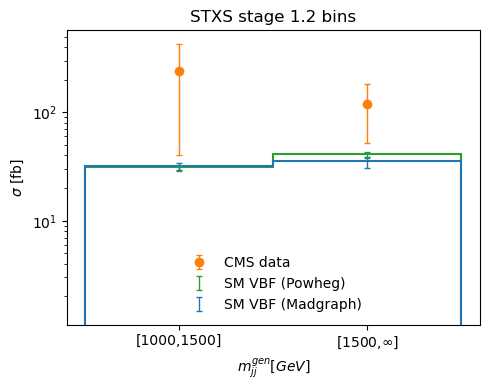

In [35]:
obs = np.array([240.0, 120.0])
cms= np.array([31.0, 41.0])
VBF = np.array([31.73, 35.29])

obs_err_up = np.array([200, 68])
obs_err_down = np.array([190, 61])
cms_err_up = np.array([2, 3])
cms_err_down = np.array([1, 2])
VBF_err_up = np.array([abs(31.73 - (1.0813452905332352 * 31.73)), abs(35.29 - (1.1310856980655979 * 35.29))])
VBF_err_down = np.array([abs(31.73 - (0.9279737600486674 * 31.73)), abs(35.29 - (0.892754463038725 * 35.29))])

print('vbf_err_up: ', VBF_err_up)
print('vbf_err_down: ', VBF_err_down)

edges = np.array([1,2,3])
centers = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(5,4))

hep.histplot(obs, bins=edges, histtype="barstep", linewidth=0, ax=ax, color='tab:orange')
hep.histplot(cms, bins=edges, histtype="barstep", ax=ax, color = 'tab:green')
hep.histplot(VBF, bins=edges, histtype="barstep", ax=ax, color = 'tab:blue')

ax.set_xticks([1.5, 2.5])
ax.set_xticklabels(["[1000,1500]", r"[1500,$\infty$]"])
ax.set_ylabel(r"$\sigma$ [fb]")
ax.set_yscale('log')
ax.set_xlabel(r'$m_{jj}^{gen} [GeV]$')

ax.errorbar(centers,obs,yerr=[obs_err_up, obs_err_down],
    fmt="o",capsize=2,elinewidth=1,color = 'tab:orange',
    label="CMS data")
ax.errorbar(centers,cms, yerr=[cms_err_up, cms_err_down],
     fmt="none",capsize=2,elinewidth=1,color = 'tab:green',
     label="SM VBF (Powheg)")
ax.errorbar(centers,VBF,yerr=[VBF_err_up, VBF_err_down],
    fmt="none",capsize=2,elinewidth=1,color = 'tab:blue',
    label="SM VBF (Madgraph)")

ax.legend(frameon=False)
plt.title('STXS stage 1.2 bins')

plt.tight_layout()
plt.show()


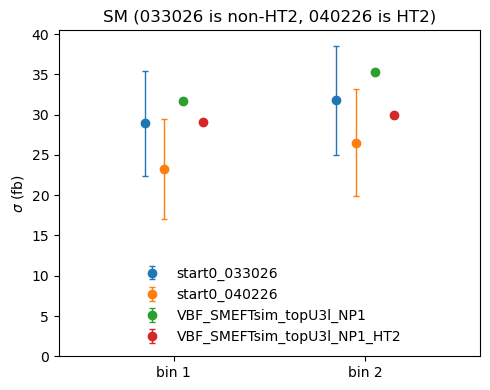

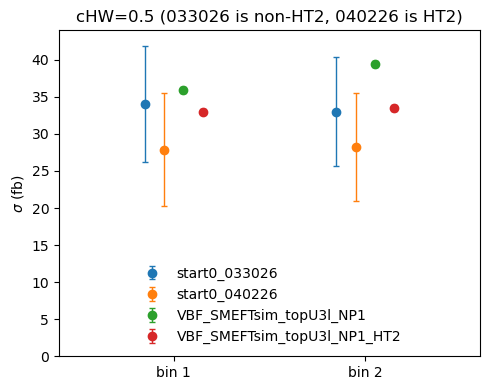

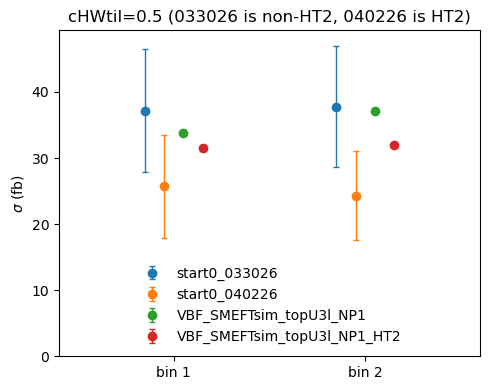

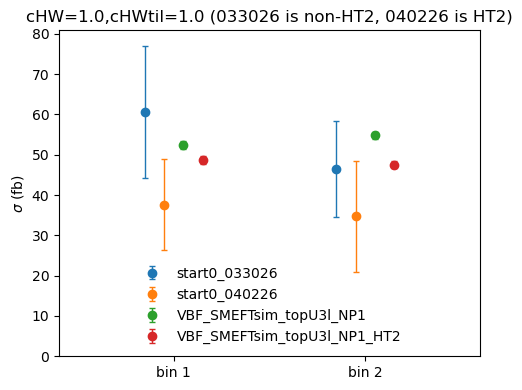

In [75]:
def stxs_plot_only_stat(coffea_name_list, reweight_point_list):
    '''Builds an STXS plot for each specified reweight point, with each one plot comparing all the specified coffeas'''
    colors = plt.cm.tab10.colors
    color_map = {name: colors[i % len(colors)] for i, name in enumerate(coffea_name_list)}
    n = len(coffea_name_list)
    offsets = np.linspace(-0.15, 0.15, n)
    
    for reweight_point in reweight_point_list:
        
        edges = np.array([1,2,3])
        centers = (edges[:-1] + edges[1:]) / 2
        fig, ax = plt.subplots(figsize=(5,4))
        
        plot_dict = {}
        
        for i, coffea_name in enumerate(coffea_name_list):
            color = color_map[coffea_name]
            x = centers + offsets[i]
            
            h = util.load(f"coffea/{coffea_name}.coffea")
            h_htxs = h["htxs"][{"wc": f"{reweight_point}"}]
            h_axis = h_htxs.axes["htxs_stage2"]
            values = h_htxs.values()
            variances = h_htxs.variances()
            codes = [h_htxs.axes["htxs_stage2"].bin(i) for i in range(h_htxs.axes["htxs_stage2"].size)]
            
            h_sumw = h["sumw_all_noEW"]
            sumw = h_sumw.value
            
            bin1_codes = [221, 222]
            bin2_codes = [223, 224]
            
            code_to_value = {code: values[i] for i, code in enumerate(codes)}
            code_to_var = {code: variances[i] for i, code in enumerate(codes)}
            
            bin1_events = sum(code_to_value.get(c, 0.0) for c in bin1_codes)
            bin1_var = sum(code_to_var.get(c, 0.0)   for c in bin1_codes)
            bin1_err = np.sqrt(bin1_var)
            bin2_events = sum(code_to_value.get(c, 0.0) for c in bin2_codes)
            bin2_var = sum(code_to_var.get(c, 0.0)   for c in bin2_codes)
            bin2_err = np.sqrt(bin2_var)
            
            MG_sigma = 3.594
            xs1 = MG_sigma * 1000.0 * (bin1_events / sumw)
            xs1_err = MG_sigma * 1000.0 * (bin1_err / sumw)
            xs2 = MG_sigma * 1000.0 * (bin2_events / sumw)
            xs2_err = MG_sigma * 1000.0 * (bin2_err / sumw)
            
            color = color_map[coffea_name]
            hep.histplot(np.array([xs1, xs2]),bins=edges,histtype='barstep',ax=ax,color=color,linewidth=0)
            ax.errorbar(x,np.array([xs1, xs2]),yerr=[[xs1_err, xs2_err], [xs1_err, xs2_err]],
                label=f'{coffea_name}',fmt="o",capsize=2,elinewidth=1,color=color)
            
        ax.set_xticks([1.5, 2.5])
        ax.set_xticklabels(["bin 1", "bin 2"])
        ax.set_ylabel(r"$\sigma$ (fb)")
        ax.legend(frameon=False)
        plt.title(f'{reweight_point} (033026 is non-HT2, 040226 is HT2)')

        plt.tight_layout()

stxs_plot_only_stat(['start0_033026', 'start0_040226', 'VBF_SMEFTsim_topU3l_NP1', 'VBF_SMEFTsim_topU3l_NP1_HT2'],
          ['SM', 'cHW=0.5', 'cHWtil=0.5', 'cHW=1.0,cHWtil=1.0'])